In [1]:
import os
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as transforms
import torchvision.models as models

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, precision_score, recall_score

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("gifgif_emotion_labels.csv")

group_defs = {
    "positive_energetic": ["happiness_score","amusement_score","excitement_score","relief_score"],
    "positive_calm":      ["satisfaction_score","contentment_score","pleasure_score","pride_score"],
    "negative_intense":   ["anger_score","fear_score","disgust_score"],
    "negative_subdued":   ["sadness_score","embarrassment_score","guilt_score","shame_score"],
    "surprise":           ["surprise_score"],
    "contempt":           ["contempt_score"],
}

# Compute grouped scores (max works best for emotion)
for g, cols in group_defs.items():
    df[g+"_gscore"] = df[cols].max(axis=1)

groups = list(group_defs.keys())
G = df[[g+"_gscore" for g in groups]].values

Top group always + any group within 85% of top

In [3]:
alpha = 0.85

top = G.max(axis=1, keepdims=True)
Y = (G >= (alpha * top)).astype(np.float32)

df_multi = df.copy()
for i, g in enumerate(groups):
    df_multi[g] = Y[:, i]

print("Average labels per GIF:", Y.sum(axis=1).mean())
print("Max labels on a GIF:", int(Y.sum(axis=1).max()))

Average labels per GIF: 1.2779872
Max labels on a GIF: 4


In [4]:
pos = Y.sum(axis=0)
neg = Y.shape[0] - pos

imbalance_df = pd.DataFrame({
    "label": groups,
    "positives": pos.astype(int),
    "pos_rate": np.round(pos / Y.shape[0], 4),
    "neg_to_pos_ratio": np.round(neg / np.maximum(pos, 1), 2)
}).sort_values("pos_rate")

print(imbalance_df.to_string(index=False))

             label  positives  pos_rate  neg_to_pos_ratio
          contempt        324    0.0531             17.83
          surprise        698    0.1144              7.74
  negative_subdued       1341    0.2198              3.55
     positive_calm       1434    0.2350              3.25
  negative_intense       1781    0.2919              2.43
positive_energetic       2219    0.3637              1.75


In [5]:
print(df.columns)

Index(['gif_id', 'gif_path', 'primary_emotion', 'primary_score',
       'total_comparisons', 'pleasure_score', 'disgust_score',
       'happiness_score', 'pride_score', 'excitement_score',
       'embarrassment_score', 'surprise_score', 'sadness_score', 'fear_score',
       'satisfaction_score', 'guilt_score', 'contempt_score', 'shame_score',
       'anger_score', 'amusement_score', 'contentment_score', 'relief_score',
       'positive_energetic_gscore', 'positive_calm_gscore',
       'negative_intense_gscore', 'negative_subdued_gscore', 'surprise_gscore',
       'contempt_gscore'],
      dtype='str')


In [6]:
alpha = 0.85

G = df[[g+"_gscore" for g in groups]].values
top = G.max(axis=1, keepdims=True)

Y = (G >= (alpha * top)).astype(np.float32)

for i, g in enumerate(groups):
    df[g] = Y[:, i]

print("Columns after adding multi-label targets:")
print(df.columns)
print("\nCheck first rows:")
print(df[groups].head())

Columns after adding multi-label targets:
Index(['gif_id', 'gif_path', 'primary_emotion', 'primary_score',
       'total_comparisons', 'pleasure_score', 'disgust_score',
       'happiness_score', 'pride_score', 'excitement_score',
       'embarrassment_score', 'surprise_score', 'sadness_score', 'fear_score',
       'satisfaction_score', 'guilt_score', 'contempt_score', 'shame_score',
       'anger_score', 'amusement_score', 'contentment_score', 'relief_score',
       'positive_energetic_gscore', 'positive_calm_gscore',
       'negative_intense_gscore', 'negative_subdued_gscore', 'surprise_gscore',
       'contempt_gscore', 'positive_energetic', 'positive_calm',
       'negative_intense', 'negative_subdued', 'surprise', 'contempt'],
      dtype='str')

Check first rows:
   positive_energetic  positive_calm  negative_intense  negative_subdued  \
0                 0.0            0.0               1.0               0.0   
1                 1.0            0.0               0.0              

In [7]:
train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

print(len(train_df), len(val_df), len(test_df))

4270 915 916


In [8]:
class GIFMultiLabelDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        gif_path = row["gif_path"]
        
        gif = Image.open(gif_path)
        frame = gif.convert("RGB")
        
        if self.transform:
            frame = self.transform(frame)
        
        label = torch.tensor(row[groups].values.astype(np.float32))
        
        return frame, label

In [9]:
transform_train = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

transform_eval = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

train_ds = GIFMultiLabelDataset(train_df, transform_train)
val_ds   = GIFMultiLabelDataset(val_df, transform_eval)
test_ds  = GIFMultiLabelDataset(test_df, transform_eval)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=8, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=8, shuffle=False)

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(pretrained=True)

num_classes = 6

model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(model.fc.in_features, num_classes)
)

model = model.to(device)

d:\IIT\Year 4\FYP\Datasets\GIFGIF_lucas\gifgif-env\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\IIT\Year 4\FYP\Datasets\GIFGIF_lucas\gifgif-env\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [11]:
pos = torch.tensor(Y.sum(axis=0), dtype=torch.float32)
neg = torch.tensor(len(Y) - pos, dtype=torch.float32)

pos_weight = (neg / (pos + 1e-6)).clamp(max=10.0)

print("pos_weight:", pos_weight)

pos_weight: tensor([ 1.7494,  3.2545,  2.4256,  3.5496,  7.7407, 10.0000])


C:\Users\akind\AppData\Local\Temp\ipykernel_11684\2696220420.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  neg = torch.tensor(len(Y) - pos, dtype=torch.float32)


In [12]:
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(device))

optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

In [13]:
print(train_df[groups].head())
print("Any NaNs in labels?", train_df[groups].isna().any().any())

      positive_energetic  positive_calm  negative_intense  negative_subdued  \
1211                 0.0            1.0               0.0               0.0   
122                  0.0            0.0               1.0               0.0   
5710                 0.0            0.0               0.0               1.0   
5137                 0.0            0.0               1.0               0.0   
4879                 0.0            1.0               0.0               0.0   

      surprise  contempt  
1211       0.0       0.0  
122        0.0       0.0  
5710       0.0       0.0  
5137       0.0       0.0  
4879       0.0       0.0  
Any NaNs in labels? False


In [14]:
import numpy as np
import torch
from sklearn.metrics import f1_score

def evaluate(loader, threshold=0.5):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            probs = torch.sigmoid(outputs)
            preds = (probs > threshold).float()

            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)

    micro = f1_score(all_labels, all_preds, average="micro", zero_division=0)
    macro = f1_score(all_labels, all_preds, average="macro", zero_division=0)

    return micro, macro

In [15]:
from tqdm import tqdm
import numpy as np

EPOCHS = 20
best_macro = 0.0
best_path = "best_multilabel_6group_resnet18_final.pth"

# NEW: history containers
train_losses = []
val_micro_scores = []
val_macro_scores = []

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    avg_loss = total_loss / len(train_loader)
    micro, macro = evaluate(val_loader)

    # NEW: store history
    train_losses.append(avg_loss)
    val_micro_scores.append(micro)
    val_macro_scores.append(macro)

    print(f"\nEpoch {epoch+1}/{EPOCHS} | "
          f"Loss: {avg_loss:.4f} | "
          f"Micro-F1: {micro:.4f} | "
          f"Macro-F1: {macro:.4f}")

    if macro > best_macro:
        best_macro = macro
        torch.save(model.state_dict(), best_path)
        print(f"✅ Saved new best model (Macro-F1 = {best_macro:.4f})")

print("\nBest Val Macro-F1:", best_macro)

Epoch 1: 100%|██████████| 534/534 [09:20<00:00,  1.05s/it]



Epoch 1/20 | Loss: 1.0835 | Micro-F1: 0.3254 | Macro-F1: 0.2919
✅ Saved new best model (Macro-F1 = 0.2919)


Epoch 2: 100%|██████████| 534/534 [09:17<00:00,  1.04s/it]



Epoch 2/20 | Loss: 1.0370 | Micro-F1: 0.3704 | Macro-F1: 0.2924
✅ Saved new best model (Macro-F1 = 0.2924)


Epoch 3: 100%|██████████| 534/534 [08:15<00:00,  1.08it/s]


...


Epoch 18/20 | Loss: 0.4334 | Micro-F1: 0.3729 | Macro-F1: 0.3216


Epoch 19: 100%|██████████| 534/534 [08:03<00:00,  1.10it/s]



Epoch 19/20 | Loss: 0.3789 | Micro-F1: 0.3661 | Macro-F1: 0.3229


Epoch 20: 100%|██████████| 534/534 [08:07<00:00,  1.10it/s]



Epoch 20/20 | Loss: 0.3706 | Micro-F1: 0.3746 | Macro-F1: 0.3445

Best Val Macro-F1: 0.36541490429207063


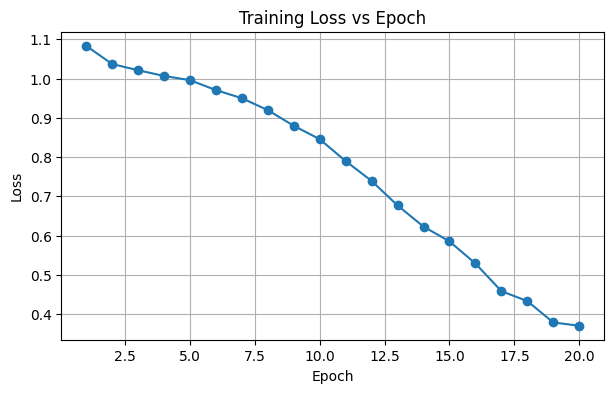

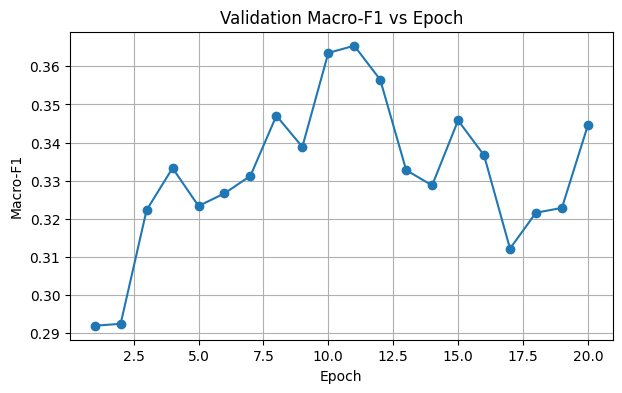

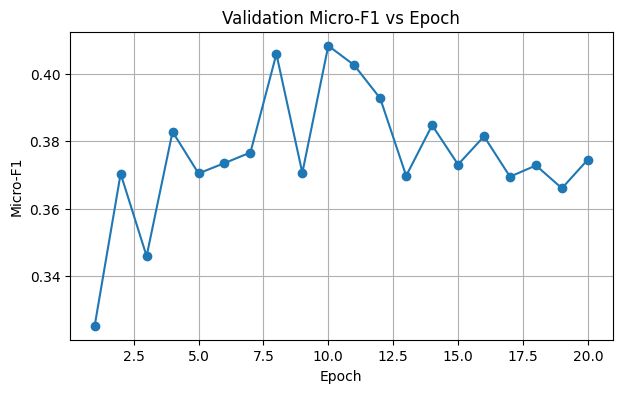

In [16]:
import matplotlib.pyplot as plt
import os

OUT_DIR = "emotion_final_plots"
os.makedirs(OUT_DIR, exist_ok=True)

epochs = range(1, len(train_losses)+1)

# Loss
plt.figure(figsize=(7,4))
plt.plot(epochs, train_losses, marker="o")
plt.title("Training Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.savefig(os.path.join(OUT_DIR, "loss_curve.png"), dpi=200)
plt.show()

# Macro-F1
plt.figure(figsize=(7,4))
plt.plot(epochs, val_macro_scores, marker="o")
plt.title("Validation Macro-F1 vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Macro-F1")
plt.grid(True)
plt.savefig(os.path.join(OUT_DIR, "val_macro_curve.png"), dpi=200)
plt.show()

# Micro-F1
plt.figure(figsize=(7,4))
plt.plot(epochs, val_micro_scores, marker="o")
plt.title("Validation Micro-F1 vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Micro-F1")
plt.grid(True)
plt.savefig(os.path.join(OUT_DIR, "val_micro_curve.png"), dpi=200)
plt.show()

Find the best threshhold

In imbalanced multi-label:

0.5 threshold often too strict

Rare classes need lower threshold (0.35–0.45)

Macro-F1 often improves significantly

In [17]:
import numpy as np
from sklearn.metrics import f1_score

# Load best model (epoch 5)
model.load_state_dict(torch.load(best_path, map_location=device))

def collect_probs_labels(loader):
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.sigmoid(outputs).cpu().numpy()
            all_probs.append(probs)
            all_labels.append(labels.numpy())
    return np.vstack(all_probs), np.vstack(all_labels)

val_probs, val_true = collect_probs_labels(val_loader)

best_t = None
best_macro = -1

for t in np.arange(0.25, 0.61, 0.05):
    val_pred = (val_probs > t).astype(int)
    macro = f1_score(val_true, val_pred, average="macro", zero_division=0)
    print(f"Threshold {t:.2f} → Macro-F1: {macro:.4f}")
    
    if macro > best_macro:
        best_macro = macro
        best_t = t

print("\nBest threshold:", best_t)
print("Best Val Macro-F1:", best_macro)

Threshold 0.25 → Macro-F1: 0.3749
Threshold 0.30 → Macro-F1: 0.3783
Threshold 0.35 → Macro-F1: 0.3829
Threshold 0.40 → Macro-F1: 0.3775
Threshold 0.45 → Macro-F1: 0.3679
Threshold 0.50 → Macro-F1: 0.3654
Threshold 0.55 → Macro-F1: 0.3494
Threshold 0.60 → Macro-F1: 0.3288

Best threshold: 0.35
Best Val Macro-F1: 0.38290849045506525


Test evaluation at threshold = 0.45

In [18]:
from sklearn.metrics import f1_score, classification_report

# make sure best model is loaded
model.load_state_dict(torch.load(best_path, map_location=device))

test_probs, test_true = collect_probs_labels(test_loader)
best_t = 0.45

test_pred = (test_probs > best_t).astype(int)

print("TEST Micro-F1:", f1_score(test_true, test_pred, average="micro", zero_division=0))
print("TEST Macro-F1:", f1_score(test_true, test_pred, average="macro", zero_division=0))
print("\nPer-label report:")
print(classification_report(test_true, test_pred, target_names=groups, zero_division=0))

TEST Micro-F1: 0.39977024698449165
TEST Macro-F1: 0.3538548690961429

Per-label report:
                    precision    recall  f1-score   support

positive_energetic       0.43      0.66      0.52       327
     positive_calm       0.29      0.56      0.39       240
  negative_intense       0.34      0.69      0.45       259
  negative_subdued       0.29      0.54      0.38       201
          surprise       0.12      0.47      0.19        92
          contempt       0.16      0.23      0.19        62

         micro avg       0.30      0.59      0.40      1181
         macro avg       0.27      0.52      0.35      1181
      weighted avg       0.32      0.59      0.41      1181
       samples avg       0.31      0.61      0.39      1181



Test evaluation at threshold = 0.35

In [25]:
from sklearn.metrics import f1_score, classification_report

# make sure best model is loaded
model.load_state_dict(torch.load(best_path, map_location=device))

test_probs, test_true = collect_probs_labels(test_loader)
best_t = 0.35

test_pred = (test_probs > best_t).astype(int)

print("TEST Micro-F1:", f1_score(test_true, test_pred, average="micro", zero_division=0))
print("TEST Macro-F1:", f1_score(test_true, test_pred, average="macro", zero_division=0))
print("\nPer-label report:")
print(classification_report(test_true, test_pred, target_names=groups, zero_division=0))

TEST Micro-F1: 0.40913415794481445
TEST Macro-F1: 0.3605635946304213

Per-label report:
                    precision    recall  f1-score   support

positive_energetic       0.43      0.81      0.56       327
     positive_calm       0.29      0.74      0.42       240
  negative_intense       0.31      0.84      0.45       259
  negative_subdued       0.26      0.66      0.37       201
          surprise       0.11      0.55      0.19        92
          contempt       0.13      0.26      0.17        62

         micro avg       0.28      0.73      0.41      1181
         macro avg       0.26      0.64      0.36      1181
      weighted avg       0.31      0.73      0.43      1181
       samples avg       0.30      0.74      0.41      1181



Find Best Threshold Per Class (Validation)

In [26]:
import numpy as np
from sklearn.metrics import f1_score

# Make sure best model is loaded
model.load_state_dict(torch.load(best_path, map_location=device))

val_probs, val_true = collect_probs_labels(val_loader)

threshold_grid = np.arange(0.20, 0.61, 0.05)

best_thresholds = {}
best_f1s = {}

for i, label in enumerate(groups):
    best_t = 0.5
    best_f1 = 0
    
    for t in threshold_grid:
        preds = (val_probs[:, i] > t).astype(int)
        f1 = f1_score(val_true[:, i], preds, zero_division=0)
        
        if f1 > best_f1:
            best_f1 = f1
            best_t = t
    
    best_thresholds[label] = best_t
    best_f1s[label] = best_f1

print("Best thresholds per class:")
for k in best_thresholds:
    print(f"{k:20s} → threshold={best_thresholds[k]:.2f}, val_f1={best_f1s[k]:.4f}")

Best thresholds per class:
positive_energetic   → threshold=0.30, val_f1=0.5495
positive_calm        → threshold=0.35, val_f1=0.3892
negative_intense     → threshold=0.35, val_f1=0.4827
negative_subdued     → threshold=0.30, val_f1=0.3950
surprise             → threshold=0.55, val_f1=0.3245
contempt             → threshold=0.60, val_f1=0.2203


Evaluate on Test Set Using Per-Class Thresholds

In [27]:
from sklearn.metrics import classification_report

test_probs, test_true = collect_probs_labels(test_loader)

# Apply class-specific thresholds
test_pred = np.zeros_like(test_probs)

for i, label in enumerate(groups):
    t = best_thresholds[label]
    test_pred[:, i] = (test_probs[:, i] > t).astype(int)

print("TEST Micro-F1:",
      f1_score(test_true, test_pred, average="micro", zero_division=0))

print("TEST Macro-F1:",
      f1_score(test_true, test_pred, average="macro", zero_division=0))

print("\nPer-label report:")
print(classification_report(test_true, test_pred,
                            target_names=groups,
                            zero_division=0))

TEST Micro-F1: 0.42474834274490547
TEST Macro-F1: 0.3571548812444462

Per-label report:
                    precision    recall  f1-score   support

positive_energetic       0.41      0.86      0.55       327
     positive_calm       0.29      0.74      0.42       240
  negative_intense       0.31      0.84      0.45       259
  negative_subdued       0.25      0.73      0.38       201
          surprise       0.13      0.39      0.20        92
          contempt       0.16      0.13      0.14        62

         micro avg       0.30      0.73      0.42      1181
         macro avg       0.26      0.61      0.36      1181
      weighted avg       0.30      0.73      0.42      1181
       samples avg       0.31      0.75      0.42      1181



In [28]:
from sklearn.metrics import hamming_loss

subset_acc = (test_pred == test_true).all(axis=1).mean()
ham = hamming_loss(test_true, test_pred)

print("Subset Accuracy:", subset_acc)
print("Hamming Loss:", ham)

Subset Accuracy: 0.03275109170305677
Hamming Loss: 0.42631004366812225


In [22]:
with open(os.path.join(OUT_DIR, "final_metrics.txt"), "w") as f:
    f.write(f"Best Val Macro-F1: {best_macro}\n")
    f.write(f"Test Micro-F1: {f1_score(test_true, test_pred, average='micro', zero_division=0)}\n")
    f.write(f"Test Macro-F1: {f1_score(test_true, test_pred, average='macro', zero_division=0)}\n")
    f.write(f"Subset Accuracy: {subset_acc}\n")
    f.write(f"Hamming Loss: {ham}\n")

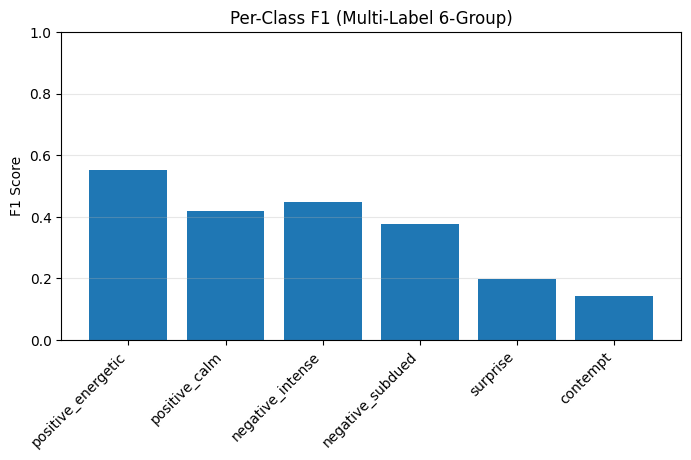

Saved: emotion_final_plots\per_class_f1.png


In [23]:
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

per_class_f1 = [f1_score(test_true[:, i], test_pred[:, i], zero_division=0) for i in range(len(groups))]

plt.figure(figsize=(8,4))
plt.bar(groups, per_class_f1)
plt.xticks(rotation=45, ha="right")
plt.ylabel("F1 Score")
plt.title("Per-Class F1 (Multi-Label 6-Group)")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)
f1_path = os.path.join(OUT_DIR, "per_class_f1.png")
plt.savefig(f1_path, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", f1_path)

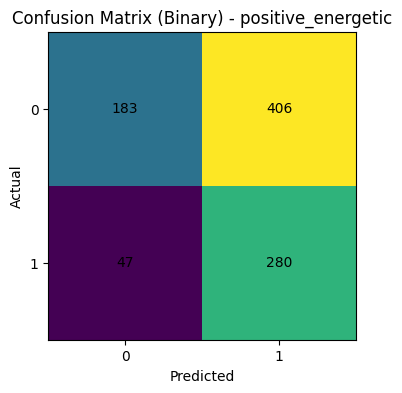

Saved: emotion_final_plots\cm_positive_energetic.png


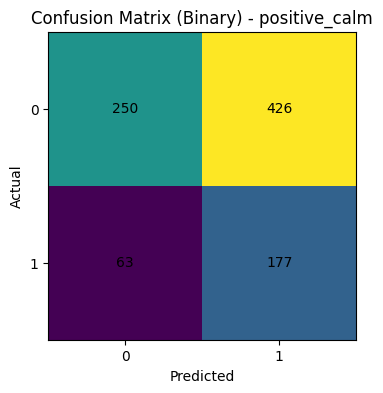

Saved: emotion_final_plots\cm_positive_calm.png


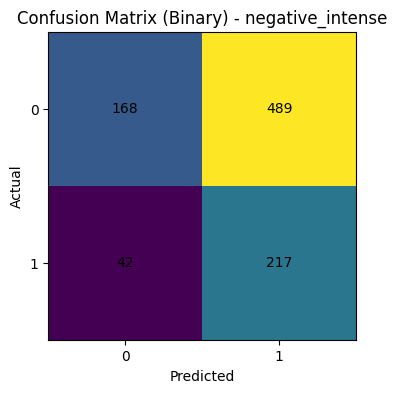

Saved: emotion_final_plots\cm_negative_intense.png


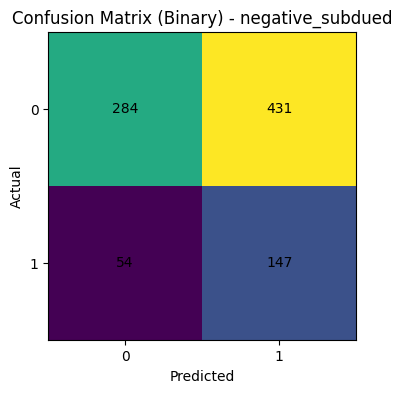

Saved: emotion_final_plots\cm_negative_subdued.png


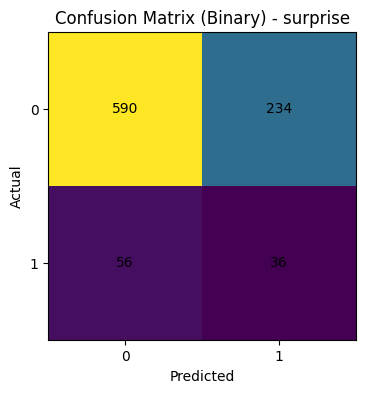

Saved: emotion_final_plots\cm_surprise.png


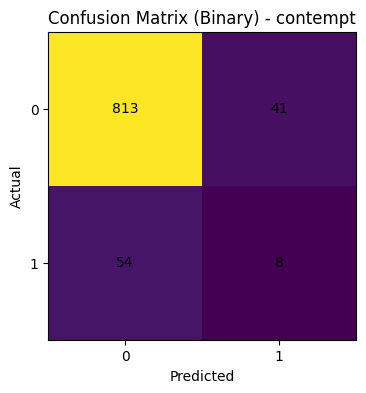

Saved: emotion_final_plots\cm_contempt.png


In [24]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

for i, label in enumerate(groups):
    cm = confusion_matrix(test_true[:, i], test_pred[:, i])
    plt.figure(figsize=(4,4))
    plt.imshow(cm)
    plt.title(f"Confusion Matrix (Binary) - {label}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks([0,1], ["0","1"])
    plt.yticks([0,1], ["0","1"])

    # annotate
    for (r,c), v in np.ndenumerate(cm):
        plt.text(c, r, str(v), ha="center", va="center")

    cm_path = os.path.join(OUT_DIR, f"cm_{label}.png")
    plt.savefig(cm_path, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", cm_path)